# Compare cell-eval results: buggy vs fixed

Loads metric CSVs from two result directories written by `scripts/run_eval_only.py` and plots the differences. Set the two paths below.

In [17]:
DIR_BUGGY = "/home/leonhafner/arc-in-vivo/debug/cmp_state_hvg/buggy"                                                                                                                                               
DIR_FIXED = "/home/leonhafner/arc-in-vivo/debug/cmp_state_hvg/fixed"
LABEL_A = "buggy"
LABEL_B = "fixed"
TOL = 1e-6  # below this, a metric is considered unchanged

In [18]:
import glob
import os

import numpy as np
import polars as pl
import matplotlib.pyplot as plt


def load_agg(results_dir: str) -> pl.DataFrame:
    frames = []
    for path in sorted(glob.glob(os.path.join(results_dir, "*_agg_results.csv"))):
        ct = os.path.basename(path).replace("_agg_results.csv", "")
        df = pl.read_csv(path).with_columns(pl.lit(ct).alias("celltype"))
        frames.append(df)
    return pl.concat(frames, how="diagonal_relaxed")


def load_perpert(results_dir: str) -> pl.DataFrame:
    frames = []
    for path in sorted(glob.glob(os.path.join(results_dir, "*_results.csv"))):
        if path.endswith("_agg_results.csv"):
            continue
        ct = os.path.basename(path).replace("_results.csv", "")
        df = pl.read_csv(path).with_columns(pl.lit(ct).alias("celltype"))
        frames.append(df)
    return pl.concat(frames, how="diagonal_relaxed")


agg_a = load_agg(DIR_BUGGY)
agg_b = load_agg(DIR_FIXED)
pert_a = load_perpert(DIR_BUGGY)
pert_b = load_perpert(DIR_FIXED)

print(f"celltypes: {sorted(set(agg_a['celltype']))}")
print(f"{LABEL_A}: agg shape {agg_a.shape}, per-pert shape {pert_a.shape}")
print(f"{LABEL_B}: agg shape {agg_b.shape}, per-pert shape {pert_b.shape}")

celltypes: ['B cells', 'DCs', 'Granulocytes', 'Monocytes', 'NK cells', 'Plasma cells', 'Proerythroblasts', 'T cells']
buggy: agg shape (72, 20), per-pert shape (120, 20)
fixed: agg shape (72, 20), per-pert shape (120, 20)


## Build the per-metric mean comparison

One row per (celltype, metric) with buggy and fixed mean values and their difference.

In [19]:
def melt_mean(df: pl.DataFrame, label: str) -> pl.DataFrame:
    stat_col = "statistic" if "statistic" in df.columns else df.columns[0]
    mean_rows = df.filter(pl.col(stat_col) == "mean").drop(stat_col)
    val_cols = [c for c in mean_rows.columns if c != "celltype"]
    return (
        mean_rows.unpivot(index=["celltype"], on=val_cols,
                          variable_name="metric", value_name=label)
                 .with_columns(pl.col(label).cast(pl.Float64, strict=False))
    )

comp = (
    melt_mean(agg_a, LABEL_A)
        .join(melt_mean(agg_b, LABEL_B), on=["celltype", "metric"], how="inner")
        .with_columns(
            abs_diff=(pl.col(LABEL_B) - pl.col(LABEL_A)).abs(),
            rel_diff=(pl.col(LABEL_B) - pl.col(LABEL_A)) / pl.col(LABEL_A).abs(),
            moved=(pl.col(LABEL_B) - pl.col(LABEL_A)).abs() > TOL,
        )
        .sort("abs_diff", descending=True, nulls_last=True)
)
comp

celltype,metric,buggy,fixed,abs_diff,rel_diff,moved
str,str,f64,f64,f64,f64,bool
"""Proerythroblasts""","""de_direction_match""",0.501587,0.622547,0.12096,0.241156,true
"""B cells""","""de_direction_match""",0.661074,0.768822,0.107749,0.16299,true
"""Monocytes""","""de_direction_match""",0.658228,0.760436,0.102207,0.155276,true
"""Plasma cells""","""de_direction_match""",0.466531,0.560866,0.094336,0.202208,true
"""NK cells""","""de_direction_match""",0.563319,0.653657,0.090338,0.160367,true
…,…,…,…,…,…,…
"""Monocytes""","""roc_auc""",0.759216,0.759216,0.0,0.0,false
"""NK cells""","""roc_auc""",0.660732,0.660732,0.0,0.0,false
"""Plasma cells""","""roc_auc""",0.599455,0.599455,0.0,0.0,false


## Plot 1 — buggy vs fixed, grouped bar chart per metric

Metrics that moved are drawn in color; unchanged metrics in light gray. One subplot per celltype.

Dropped from this plot (scale > 2.0): ['de_nsig_counts_pred', 'de_nsig_counts_real']


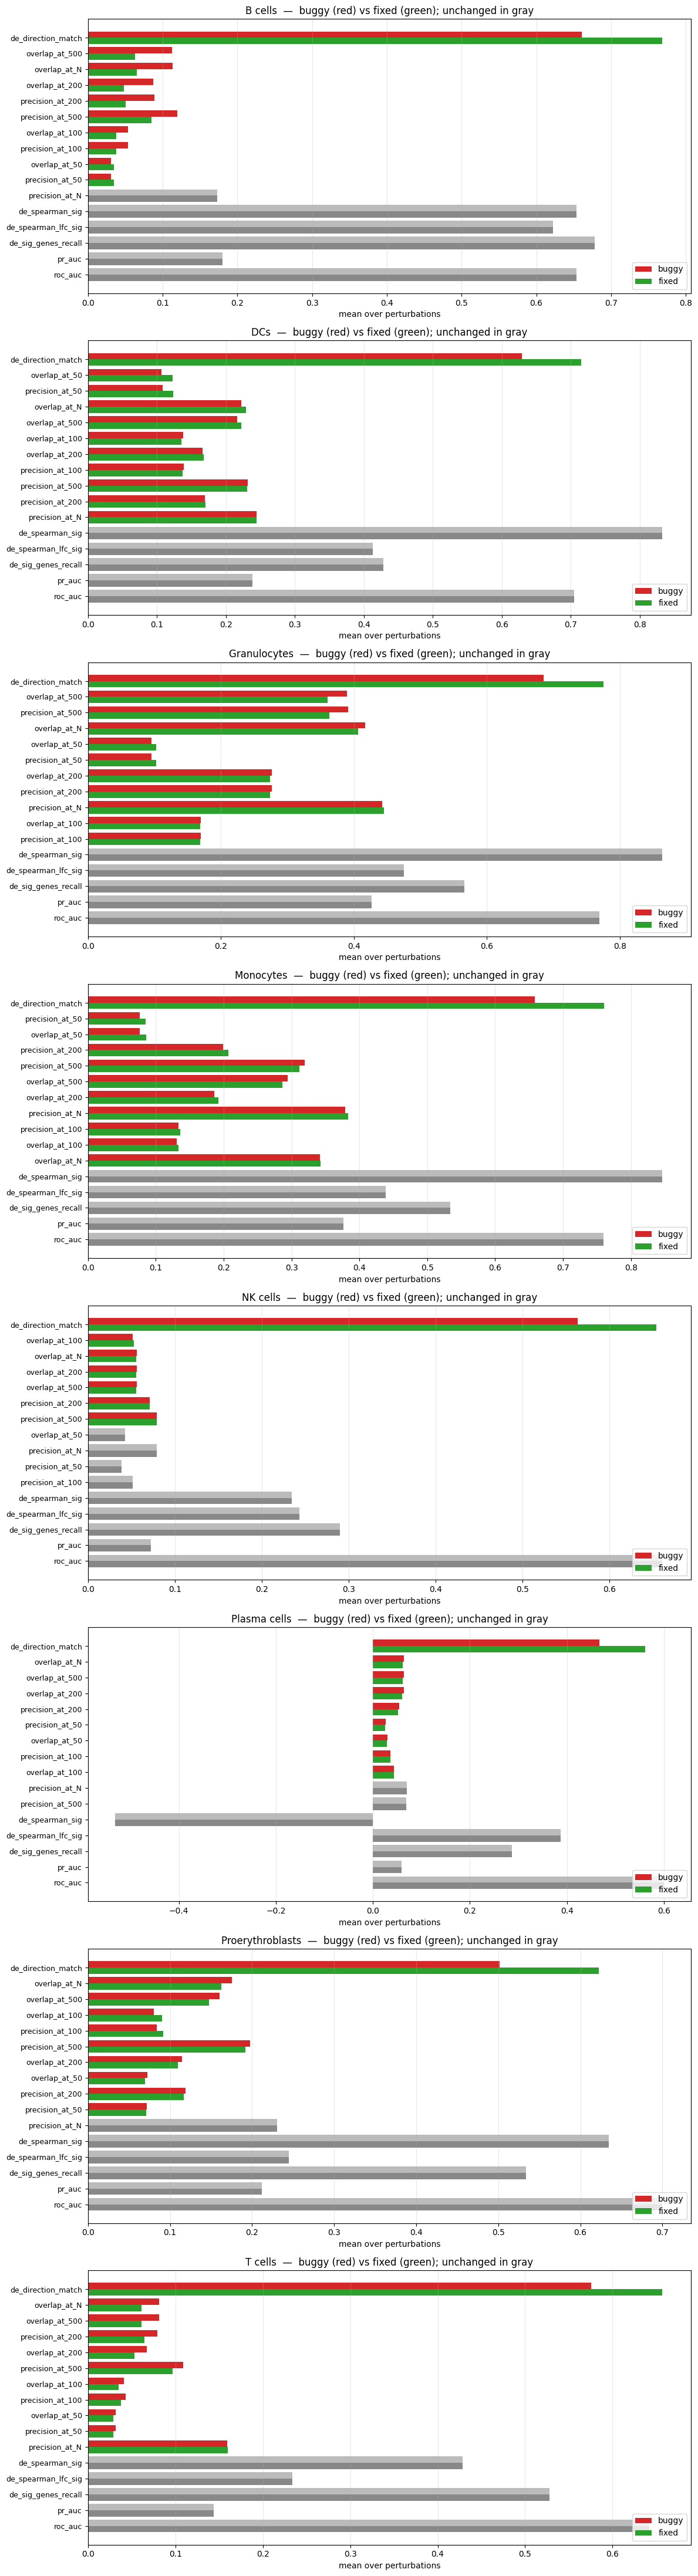

In [20]:
celltypes = sorted(set(comp["celltype"].to_list()))

# Drop metrics that live on a count-scale (e.g. de_nsig_counts_*) so they don't
# crush the 0-1 metrics into an invisible sliver near zero.
MAX_PLOT_VAL = 2.0
scale_keep = (
    comp.group_by("metric")
        .agg(pl.max_horizontal([pl.col(LABEL_A).abs().max(),
                                pl.col(LABEL_B).abs().max()]).alias("max_val"))
        .filter(pl.col("max_val") <= MAX_PLOT_VAL)["metric"].to_list()
)
plot_comp = comp.filter(pl.col("metric").is_in(scale_keep))
dropped = sorted(set(comp["metric"].to_list()) - set(scale_keep))
if dropped:
    print(f"Dropped from this plot (scale > {MAX_PLOT_VAL}): {dropped}")

fig, axes = plt.subplots(len(celltypes), 1, figsize=(12, 5.5 * len(celltypes)), squeeze=False)

for ax, ct in zip(axes[:, 0], celltypes):
    sub = plot_comp.filter(pl.col("celltype") == ct).sort("abs_diff", descending=True, nulls_last=True)
    metrics = sub["metric"].to_list()
    buggy = sub[LABEL_A].to_numpy()
    fixed = sub[LABEL_B].to_numpy()
    moved = sub["moved"].to_numpy()

    y = np.arange(len(metrics))
    h = 0.4
    ax.barh(y - h/2, buggy, height=h, label=LABEL_A,
            color=[("#d62728" if m else "#bbbbbb") for m in moved])
    ax.barh(y + h/2, fixed, height=h, label=LABEL_B,
            color=[("#2ca02c" if m else "#888888") for m in moved])
    ax.set_yticks(y)
    ax.set_yticklabels(metrics, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("mean over perturbations")
    ax.set_title(f"{ct}  —  {LABEL_A} (red) vs {LABEL_B} (green); unchanged in gray")
    ax.grid(axis="x", alpha=0.3)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## Plot 2 — relative change per metric

`(fixed - buggy) / |buggy|`. Negative bars = fix lowered the metric; positive = fix raised it. One subplot per celltype. Unchanged metrics omitted.

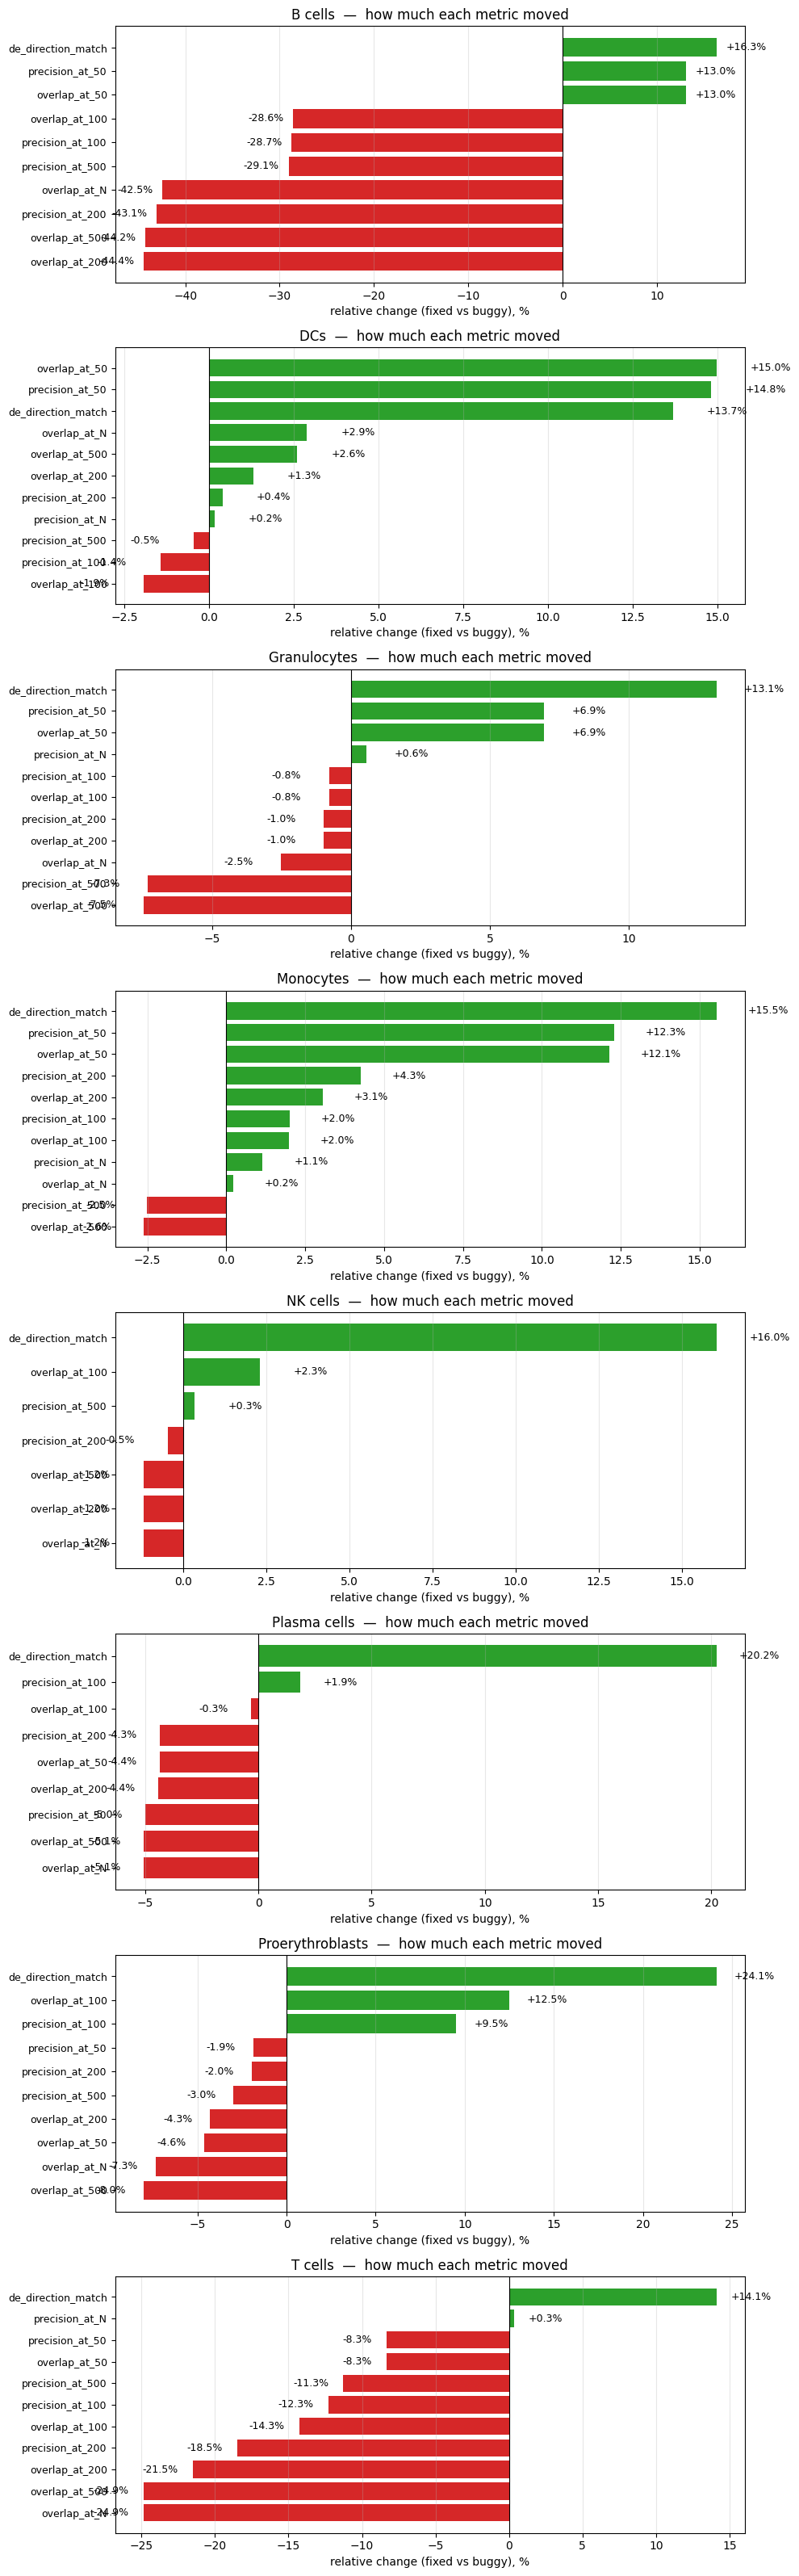

In [21]:
moved_only = comp.filter(pl.col("moved"))

fig, axes = plt.subplots(len(celltypes), 1, figsize=(10, 4 * len(celltypes)), squeeze=False)
for ax, ct in zip(axes[:, 0], celltypes):
    sub = moved_only.filter(pl.col("celltype") == ct).sort("rel_diff")
    if sub.is_empty():
        ax.text(0.5, 0.5, "no metrics moved", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(ct)
        continue
    metrics = sub["metric"].to_list()
    rel = sub["rel_diff"].to_numpy() * 100  # percent
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in rel]
    y = np.arange(len(metrics))
    ax.barh(y, rel, color=colors)
    for yi, val in zip(y, rel):
        ax.text(val + (1 if val >= 0 else -1), yi, f"{val:+.1f}%",
                va="center", ha="left" if val >= 0 else "right", fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(metrics, fontsize=9)
    ax.set_xlabel(f"relative change ({LABEL_B} vs {LABEL_A}), %")
    ax.set_title(f"{ct}  —  how much each metric moved")
    ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## Plot 3 — per-perturbation scatter for biggest movers

One point per perturbation. Diagonal = no change. Points above = fix raised the metric; below = fix lowered it.

drilling into: ['de_direction_match', 'overlap_at_500', 'overlap_at_N', 'overlap_at_200', 'precision_at_200', 'precision_at_500']
join on: ['perturbation', 'celltype']


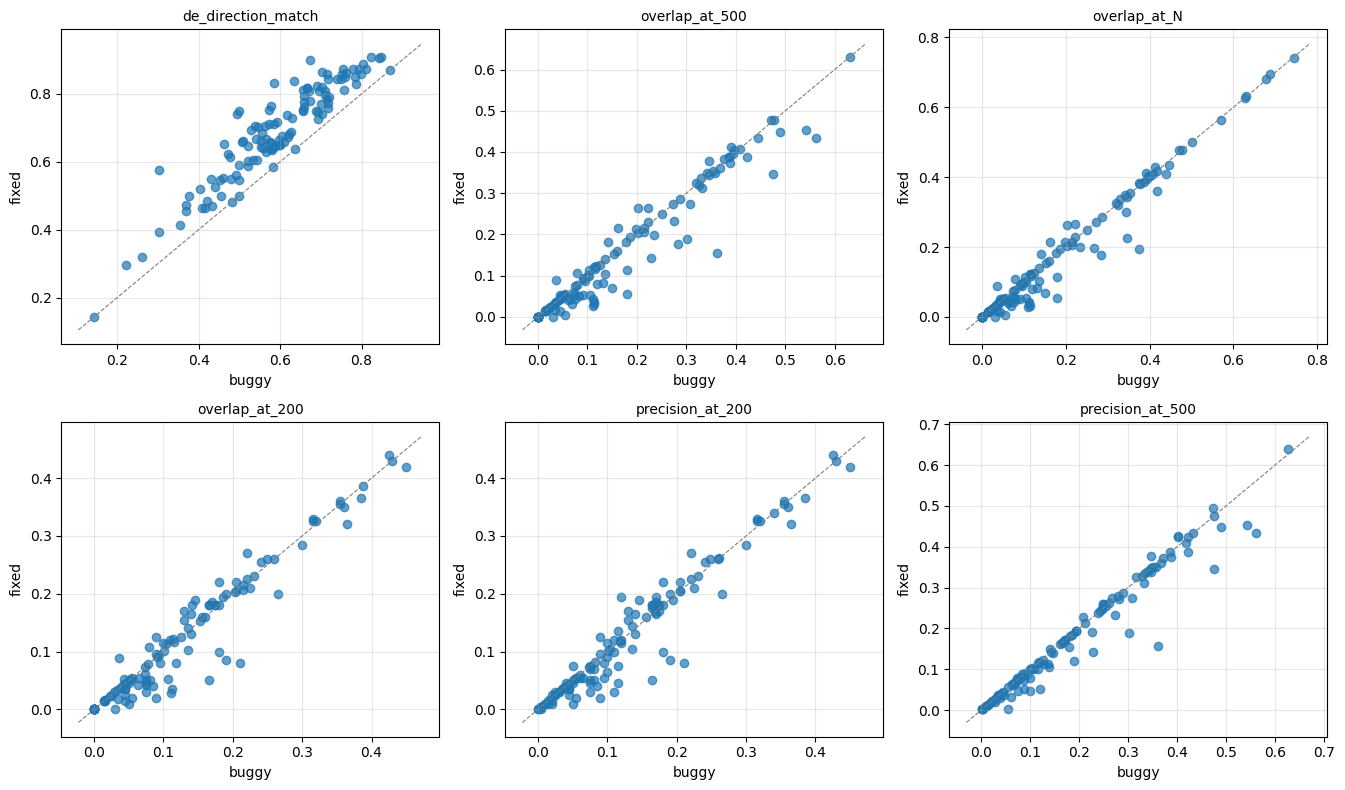

In [22]:
TOP_N = 6
top_metrics = (
    moved_only.sort("abs_diff", descending=True, nulls_last=True)["metric"]
              .unique(maintain_order=True).to_list()[:TOP_N]
)
print("drilling into:", top_metrics)

# join per-pert frames on the perturbation + celltype keys
join_key = [c for c in pert_a.columns
            if c.lower() in ("perturbation", "target", "target_gene_name", "celltype")]
print("join on:", join_key)

n_cols = 3
n_rows = (len(top_metrics) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows), squeeze=False)

for i, metric in enumerate(top_metrics):
    ax = axes[i // n_cols, i % n_cols]
    if metric not in pert_a.columns or metric not in pert_b.columns:
        ax.set_title(f"{metric}\n(not per-pert)")
        ax.axis("off")
        continue
    side = (
        pert_a.select([*join_key, metric]).rename({metric: f"{metric}__a"})
              .join(pert_b.select([*join_key, metric]).rename({metric: f"{metric}__b"}),
                    on=join_key, how="inner")
    )
    xs = side[f"{metric}__a"].to_numpy()
    ys = side[f"{metric}__b"].to_numpy()
    mask = np.isfinite(xs) & np.isfinite(ys)
    xs, ys = xs[mask], ys[mask]
    if xs.size == 0:
        ax.set_title(f"{metric}\n(no finite pairs)")
        ax.axis("off")
        continue
    lo = float(min(xs.min(), ys.min()))
    hi = float(max(xs.max(), ys.max()))
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="gray", linewidth=0.8, linestyle="--")
    ax.scatter(xs, ys, alpha=0.7)
    ax.set_xlabel(f"{LABEL_A}")
    ax.set_ylabel(f"{LABEL_B}")
    ax.set_title(metric, fontsize=10)
    ax.grid(alpha=0.3)

# hide any unused panels
for j in range(len(top_metrics), n_rows * n_cols):
    axes[j // n_cols, j % n_cols].axis("off")

plt.tight_layout()
plt.show()

## Plot 4 — summary heatmap (only useful for multi-celltype runs)

Rows = metrics, columns = celltypes, color = relative change. Skipped automatically if only one celltype.

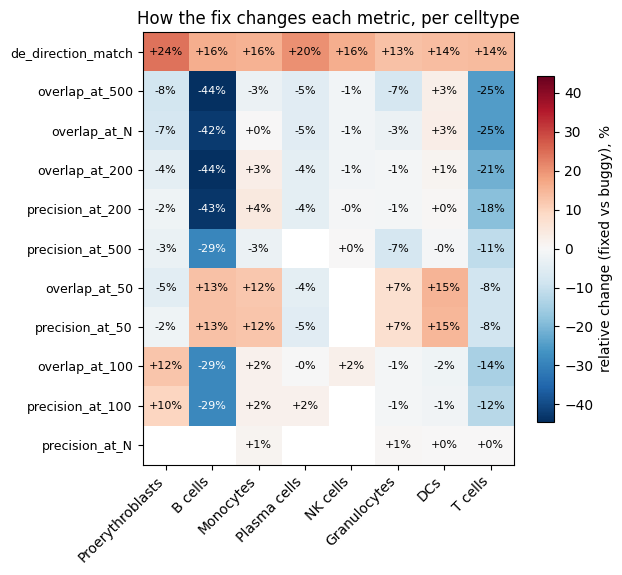

In [23]:
if len(celltypes) > 1:
    pivot = (
        moved_only.with_columns((pl.col("rel_diff") * 100).alias("pct"))
                  .pivot(index="metric", on="celltype", values="pct")
    )
    metrics = pivot["metric"].to_list()
    mat = pivot.drop("metric").to_numpy()
    vmax = float(np.nanmax(np.abs(mat))) if np.isfinite(mat).any() else 1.0

    fig, ax = plt.subplots(figsize=(1.5 + 0.6 * len(celltypes), 0.35 * len(metrics) + 2))
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(celltypes)))
    ax.set_xticklabels(pivot.columns[1:], rotation=45, ha="right")
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metrics, fontsize=9)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:+.0f}%", ha="center", va="center", fontsize=8,
                        color="white" if abs(v) > 0.6 * vmax else "black")
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(f"relative change ({LABEL_B} vs {LABEL_A}), %")
    ax.set_title("How the fix changes each metric, per celltype")
    plt.tight_layout()
    plt.show()
else:
    print("Only one celltype — heatmap skipped.")

## Summary table

In [24]:
n_moved = moved_only.height
n_total = comp.height
print(f"{n_moved}/{n_total} metric values moved (|abs_diff| > {TOL})")
print()
print("Unchanged metrics:")
for m in sorted(set(comp.filter(~pl.col("moved"))["metric"].to_list())):
    print(f"  - {m}")

80/144 metric values moved (|abs_diff| > 1e-06)

Unchanged metrics:
  - de_nsig_counts_pred
  - de_nsig_counts_real
  - de_sig_genes_recall
  - de_spearman_lfc_sig
  - de_spearman_sig
  - overlap_at_50
  - pr_auc
  - precision_at_100
  - precision_at_50
  - precision_at_500
  - precision_at_N
  - roc_auc
